#  Dataset scRNA-seq: Classificação do Microambiente do Câncer

### Atributos
- Os dados contém 10 atributos, sendo eles:
    - **Pregnancies:** Quantidade de vezes que a paciente já esteve grávida;
    - **Glucose:** Concentração de glicose no plasma 2 horas após um teste de tolerância à glicose oral;
    - **BloodPressure:** Pressão arterial diastólica (em mmHg);
    - **SkinThickness:** Espessura da dobra cutânea no tríceps (em milímetros);
    - **Insulin:** Nível de insulina sérica após 2 horas de teste (em µU/mL);
    - **BMI:** Índice de Massa Corporal (IMC);
    - **DiabetesPedigreeFunction:** Probabilidade hereditária de diabetes com base no histórico familiar;
    - **Age:** Idade da paciente (em anos);
    - **Outcome:** Resultado do paciente: 1 - tem diabetes; 0 - paciente não tem diabétes.

### Quantidade de Instâncias
- O dataset apresenta 768 amostras;

### Origem e Datas
- Os dados constados no dataset foram adaptados das pesquisar do National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) e publicados no site kaggle.com. Contém dados do ano de 2023 ~ 2024.

### Licença
- O dataset é licenciado pelo MIT e tem seu uso livre principalmente utilizado em pesquisas de aprendizado de máquina sobre saúde e diagnósticos médicos.

### Discursões Éticas
- A análise explorativa do dataset não apresentar nenhuma questão moral negativa relacionada as pessoas que tiveram seus dados coletados. Não há informações que possam idenficar ou associar diretamente a pessoa e os dados coletados. 
    Por se tratar de uma análise relacionada diretamentea diabetes, a análise deve ser feita tomando como base as melhores práticas com a finalidade de encontrar resultados válidos que não compromentam a saúde de pessoas afetadas pela doeça.

In [1]:
# bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# carregamento inicial dos dados
df = pd.read_csv("../data/raw/scRNA-seq.csv", encoding='latin-1')

In [3]:
# visualização inicial
df.head()

,Cell_ID,Cell_Type,Disease_Status,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1
0,C0001,T_Cell,Tumor,5.565866,4.546474,10.532535,2.113285,0.951138,9.580415,7.818137
1,C0002,T_Cell,Tumor,5.351163,3.840752,10.642705,4.361618,0.952454,10.540695,8.298277
2,C0003,T_Cell,Tumor,4.935363,2.271616,10.389736,2.839926,1.906194,8.416975,7.158779
3,C0004,Cancer,Tumor,4.095084,14.881377,3.268237,3.204284,9.922546,7.357785,0.016234
4,C0005,Fibroblast,Tumor,4.669715,5.444694,2.561298,14.046708,3.126553,3.372407,11.646391


In [4]:
# visualização das informações principais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cell_ID               3000 non-null   object 
 1   Cell_Type             3000 non-null   object 
 2   Disease_Status        3000 non-null   object 
 3   Gene_E_Housekeeping   3000 non-null   float64
 4   Gene_A_Oncogene       3000 non-null   float64
 5   Gene_B_Immune         3000 non-null   float64
 6   Gene_C_Stromal        3000 non-null   float64
 7   Gene_D_Therapy        3000 non-null   float64
 8   Pathway_Score_Inflam  3000 non-null   float64
 9   UMAP_1                3000 non-null   float64
dtypes: float64(7), object(3)
memory usage: 234.5+ KB


In [6]:
# validando a existencia valores ausentes ou falsos zeros
df.isnull().sum()

cols_with_invalid_zero = ["Gene_E_Housekeeping", "Gene_A_Oncogene", "Gene_B_Immune", "Gene_C_Stromal", "Gene_D_Therapy", "Pathway_Score_Inflam", "UMAP_1"]
(df[cols_with_invalid_zero] <= 0).sum()

Gene_E_Housekeeping      0
Gene_A_Oncogene          0
Gene_B_Immune            0
Gene_C_Stromal           0
Gene_D_Therapy           0
Pathway_Score_Inflam     0
UMAP_1                  16
dtype: int64

In [7]:
# estatísticas descritivas
df.describe(include='all')

,Cell_ID,Cell_Type,Disease_Status,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1
count,3000,3000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
unique,3000,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,C0001,T_Cell,Tumor,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1000,2595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,5.002702,7.319094,5.982890,6.852504,4.952360,7.043063,6.516869
std,NaN,NaN,NaN,0.495695,4.959009,4.383173,4.861748,3.692807,3.424917,3.970911
min,NaN,NaN,NaN,3.436678,1.087581,1.015551,1.176086,0.500000,1.000000,-0.799966
25%,NaN,NaN,NaN,4.658408,3.286695,2.525109,3.011726,2.004656,4.276713,1.990183
50%,NaN,NaN,NaN,4.979579,4.773690,3.517219,4.144346,3.143158,6.732012,7.010630
75%,NaN,NaN,NaN,5.326971,12.947793,11.269680,12.645769,9.255951,9.795390,10.563544


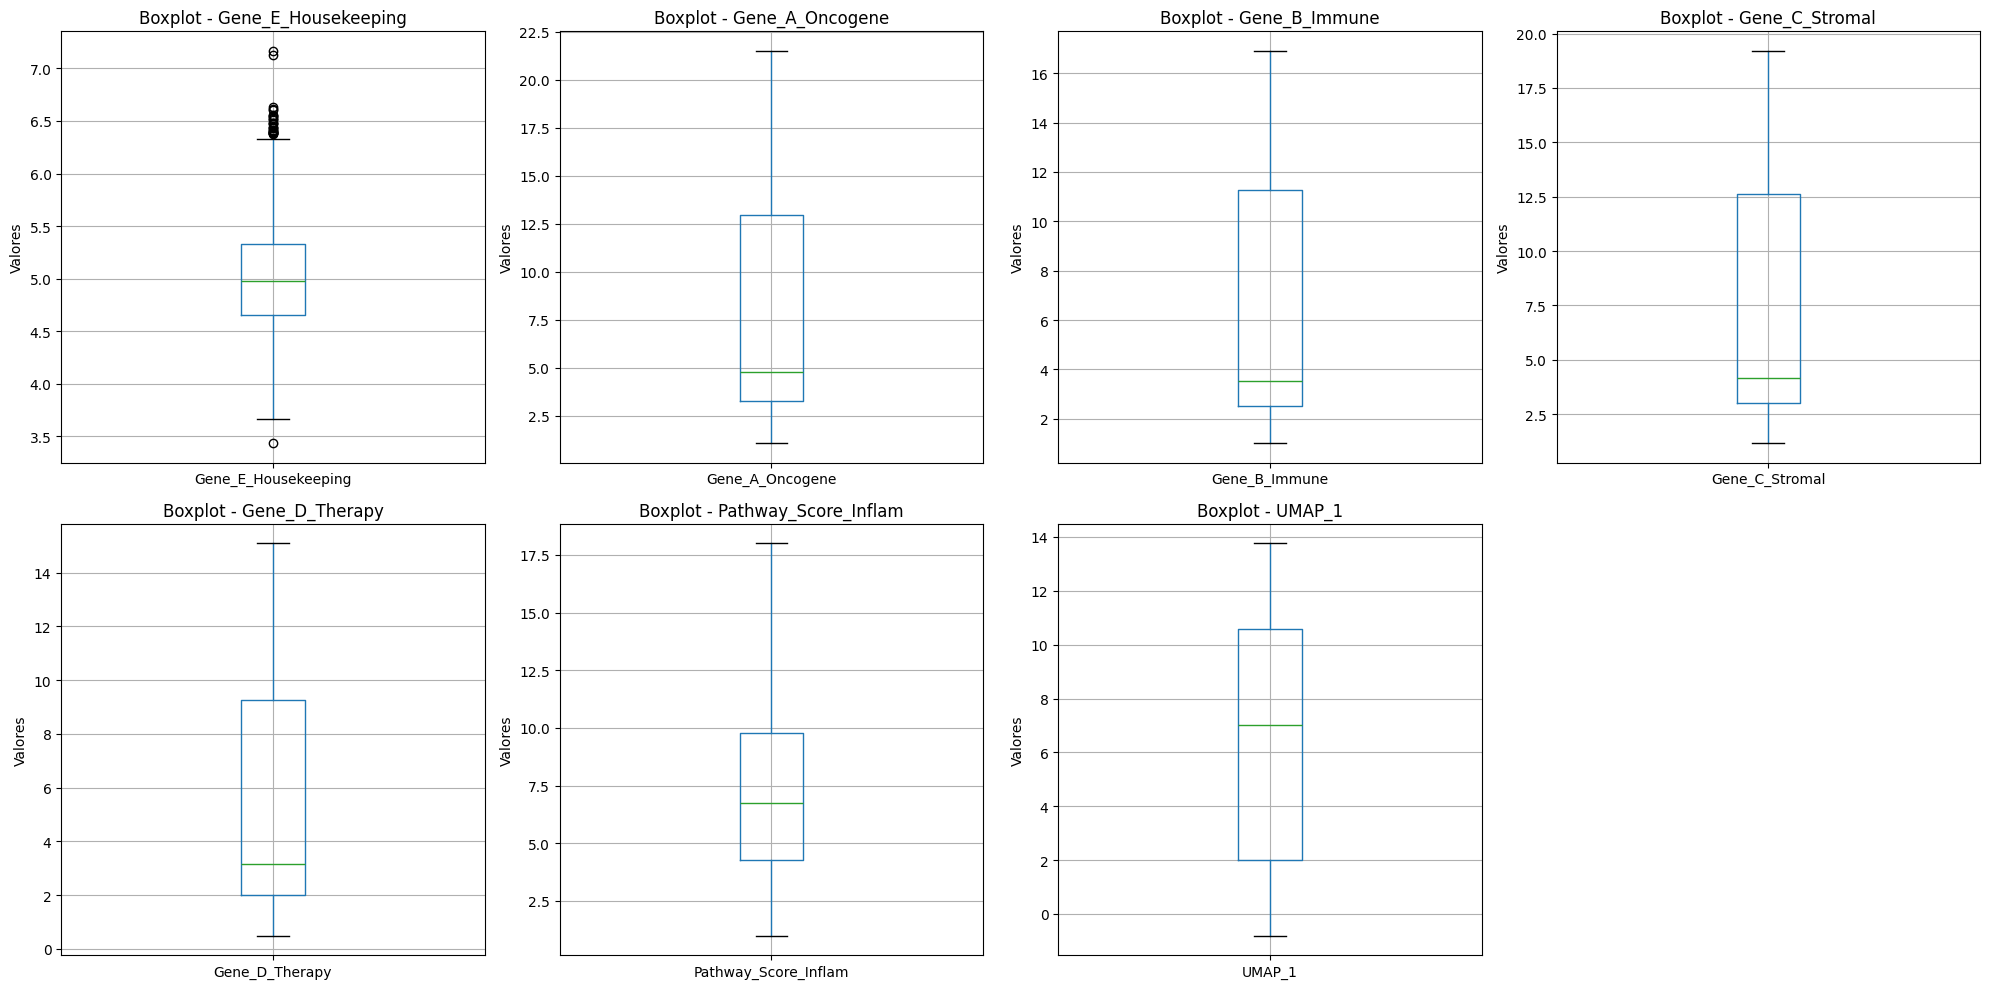

In [16]:
# Cada coluna em um subplot separado
colunas_numericas = df.select_dtypes(include=[np.number]).columns
n_cols = len(colunas_numericas)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, coluna in enumerate(colunas_numericas):
    df.boxplot(column=coluna, ax=axes[i])
    axes[i].set_title(f'Boxplot - {coluna}')
    axes[i].set_ylabel('Valores')

# Remove eixos vazios se tiver menos de 8 colunas
for j in range(len(colunas_numericas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
with_removed_zeros = df.copy()
# Calcular Z-score para todas as colunas numéricas
z_scores = np.abs(stats.zscore(with_removed_zeros.select_dtypes(include=[np.number])))

# Criar máscara para linhas sem outliers
mask = (z_scores < 3).all(axis=1)

# Remover outliers
df_no_outliers = with_removed_zeros[mask]

print("Linhas originais:", with_removed_zeros.shape[0])
print("Linhas sem outliers:", df_no_outliers.shape[0])


Linhas originais: 3000
Linhas sem outliers: 2987


In [19]:
# Supondo que seu DataFrame final seja chamado df
df_no_outliers.to_csv("../data/processed/scRNA-seq.csv", index=False)

In [22]:
print("Colunas disponíveis:")
print(df_no_outliers.columns.tolist())
print("\nPrimeiras linhas:")
print(df_no_outliers.head())

Colunas disponíveis:
['Cell_ID', 'Cell_Type', 'Disease_Status', 'Gene_E_Housekeeping', 'Gene_A_Oncogene', 'Gene_B_Immune', 'Gene_C_Stromal', 'Gene_D_Therapy', 'Pathway_Score_Inflam', 'UMAP_1']

Primeiras linhas:
  Cell_ID   Cell_Type Disease_Status  Gene_E_Housekeeping  Gene_A_Oncogene  \
0   C0001      T_Cell          Tumor             5.565866         4.546474   
1   C0002      T_Cell          Tumor             5.351163         3.840752   
2   C0003      T_Cell          Tumor             4.935363         2.271616   
3   C0004      Cancer          Tumor             4.095084        14.881377   
4   C0005  Fibroblast          Tumor             4.669715         5.444694   

   Gene_B_Immune  Gene_C_Stromal  Gene_D_Therapy  Pathway_Score_Inflam  \
0      10.532535        2.113285        0.951138              9.580415   
1      10.642705        4.361618        0.952454             10.540695   
2      10.389736        2.839926        1.906194              8.416975   
3       3.268237       

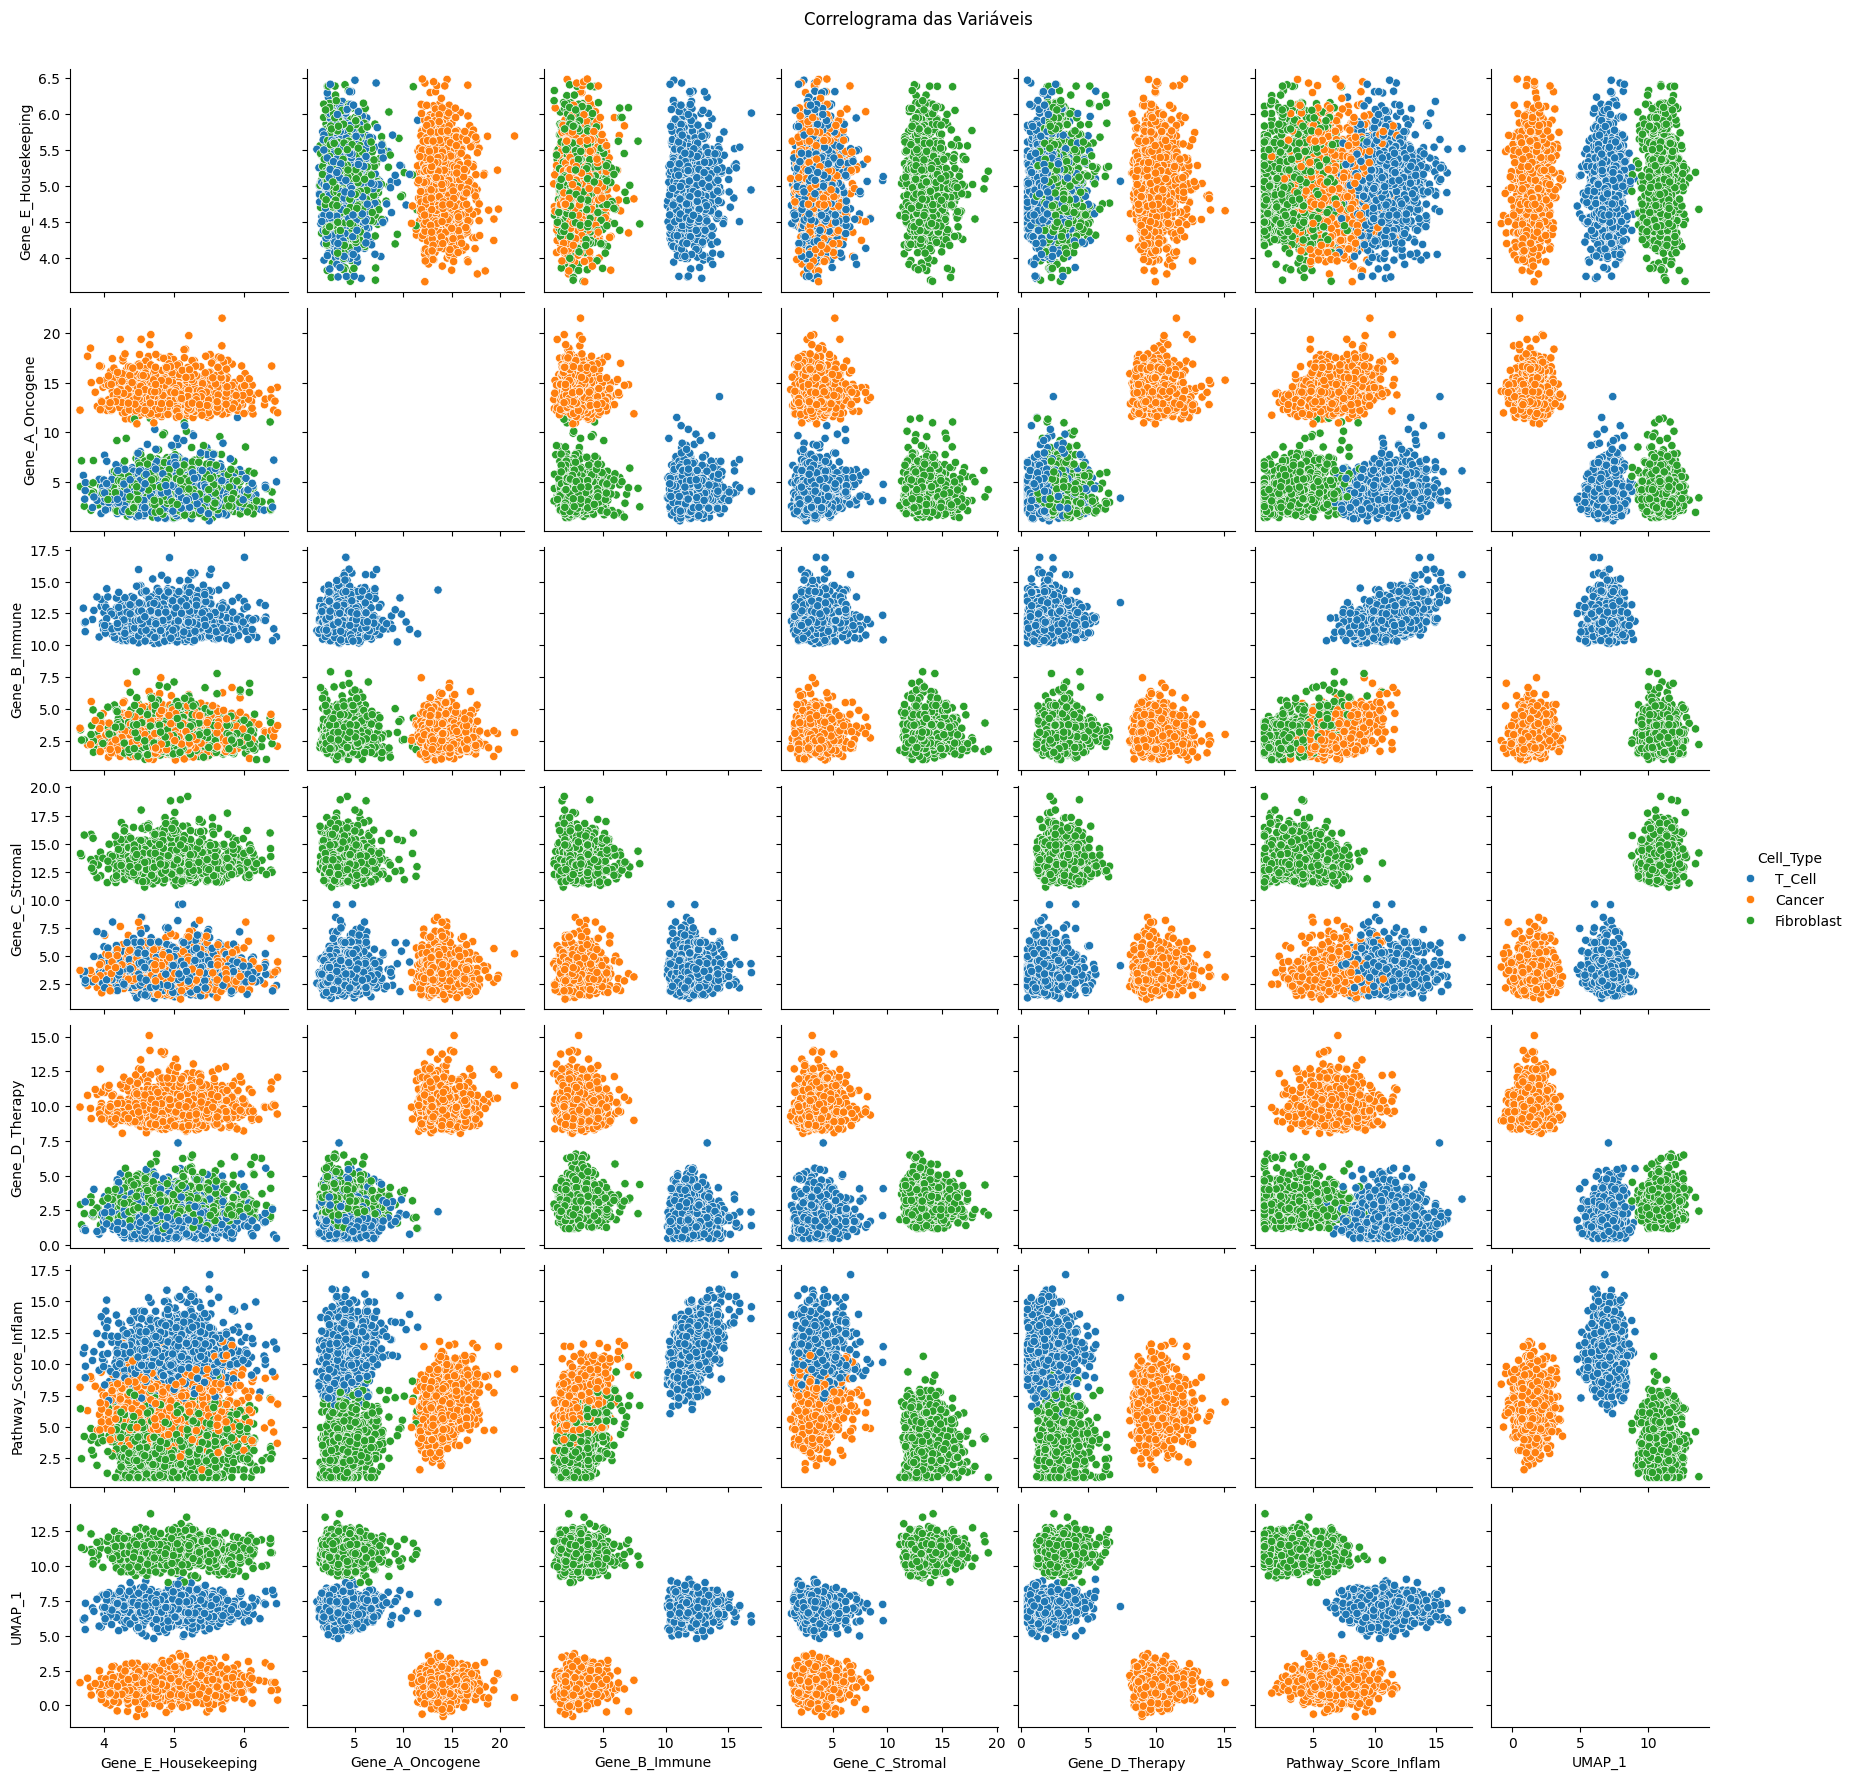

In [25]:
sns.pairplot(df_no_outliers, hue="Cell_Type", diag_kind='kdes')
plt.suptitle("Correlograma das Variáveis", y=1.02)
plt.show()

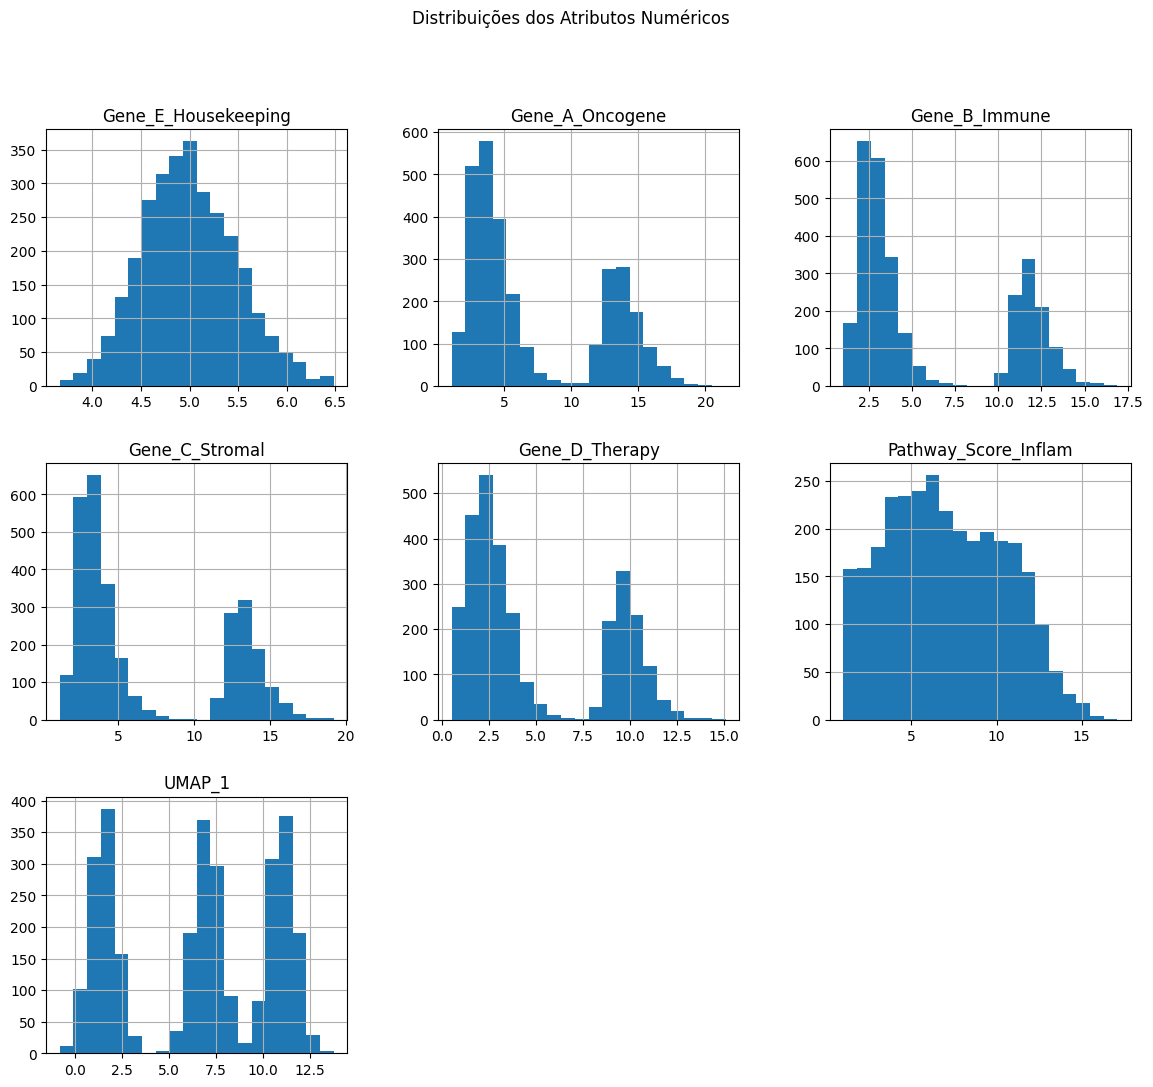

In [26]:
num_cols = df_no_outliers.select_dtypes(include=[np.number]).columns

df_no_outliers[num_cols].hist(figsize=(14, 12), bins=20)
plt.suptitle("Distribuições dos Atributos Numéricos")
plt.show()

<Figure size 1400x1000 with 0 Axes>

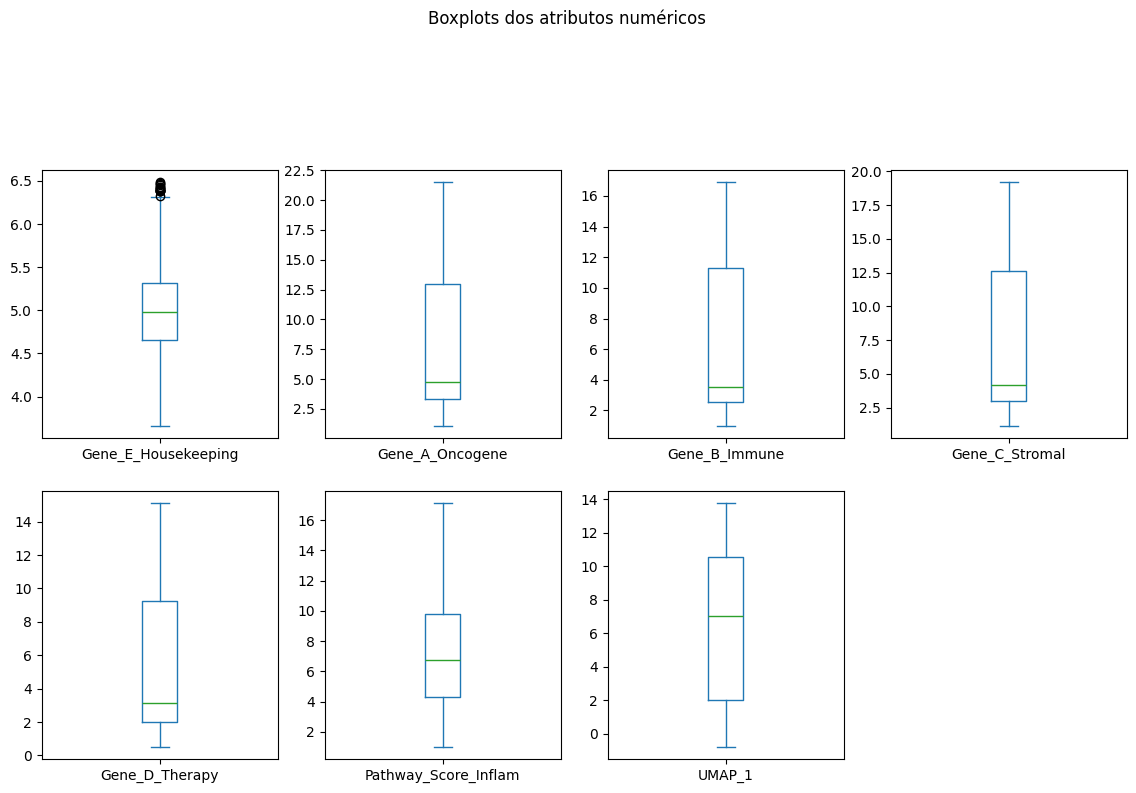

In [27]:
plt.figure(figsize=(14, 10))
df_no_outliers[num_cols].plot(kind="box", subplots=True, layout=(4, 4), figsize=(14,16))
plt.suptitle("Boxplots dos atributos numéricos")
plt.show()

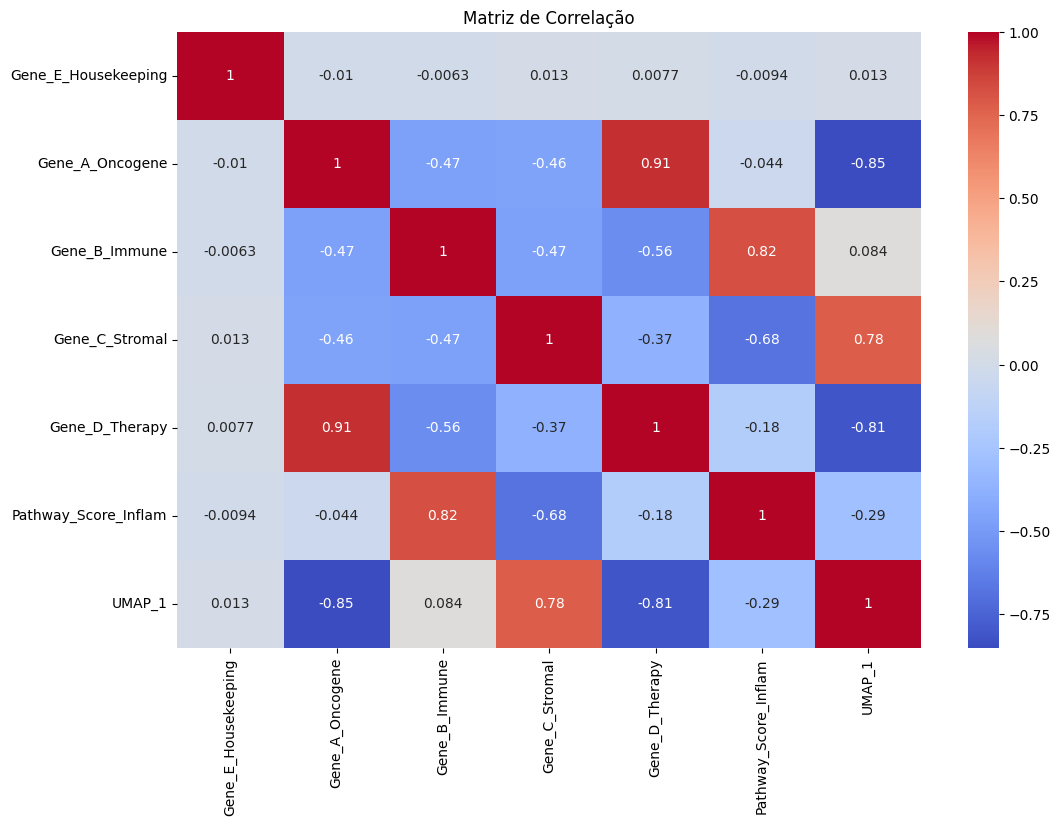

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_no_outliers[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()